# Shoaling Trajectory Grid

Fast 5x7 trajectory-grid view for one 35-fish selection experiment. This notebook uses the slim selection notebook's `processingSettings.csv` as an experiment index and reads only the requested raw x/y trajectory columns.

## Settings

In [1]:
from pathlib import Path
import glob
import hashlib
import json
import math
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

repo_candidate = Path.cwd()
if repo_candidate.name == 'Analyses':
    repo_candidate = repo_candidate.parent
CODE_DIR = Path(os.environ.get('JLSOCIALBEHAVIOR_CODE_DIR', repo_candidate)).resolve()
os.chdir(CODE_DIR)

# Experiment index and animal metadata from the slim selection notebook. Edit these paths first for other datasets.
PROCESSING_SETTINGS_CSV = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing/processingSettings.csv'
META_FOLDER = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/QTL/'
META_FILE = 'MetaData_QTL.xlsx'
OUTPUT_DIR = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/'

# Experiment selection. Folder wins when set; otherwise SELECT_EXPERIMENT_INDEX is used.
SELECT_EXPERIMENT_FOLDER = None #just the folder name, you don't need the full path. Set to None to use SELECT_EXPERIMENT_INDEX instead.
SELECT_EXPERIMENT_INDEX = 8

# Time window controls. Default is first 2 hours; set USE_FULL_RECORDING=True to ignore TIME_WINDOW_MIN.
TIME_WINDOW_MIN = (60, 90)
USE_FULL_RECORDING = False
FRAME_STRIDE = 30 # Carlos: Number of frames to skip between trajectory points. A value of 30 samples 1 frame per second. Set to 1 to use all frames, but this will be slow and probably not that informative.

# Data and output controls.
N_FISH = 35
FPS = 30
USE_TRAJECTORY_CACHE = True
SAVE_FIGURES = True
FIGURE_DPI = 180

# Absolute time-occupancy heatmap controls for outlier screening.
# Each heatmap bin stores seconds spent at sampled x/y positions in that bin.
# This makes the colors show where a fish spent time; speed stays in labels.
MOVEMENT_HEATMAP_BINS = 80
MOVEMENT_HEATMAP_CMAP = 'viridis'
# Use one shared color scale across all 35 fish so bright panels are comparable.
# The 99th percentile avoids letting one extreme bin wash out the rest of the grid.
MOVEMENT_HEATMAP_VMAX_PERCENTILE = 99
ARENA_OCCUPANCY_RADIUS_PERCENTILE = 99.5
ARENA_EVENNESS_ZMAD_THRESHOLD = 1.5
ARENA_RADIUS_ZMAD_THRESHOLD = 1.5

os.makedirs(OUTPUT_DIR, exist_ok=True)
CACHE_DIR = os.path.join(OUTPUT_DIR, 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)

print('Using repository:', CODE_DIR)
print('Using processing settings:', PROCESSING_SETTINGS_CSV)
print('Using animal metadata:', os.path.join(META_FOLDER, META_FILE))
print('Writing trajectory outputs to:', OUTPUT_DIR)

Using repository: C:\Users\crodri19\larschpostdoc_analyses\selection_shoaling\jlsocialbehavior
Using processing settings: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_processing/processingSettings.csv
Using animal metadata: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/QTL/MetaData_QTL.xlsx
Writing trajectory outputs to: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/


## Helpers

In [2]:
# Keep only tiny helpers that are reused by more than one plotting cell.
# This function makes labels safe to use in filenames by replacing spaces,
# slashes, and other special characters with underscores.
def safe_filename(value):
    text = str(value).strip()
    return ''.join(char if char.isalnum() or char in '._-' else '_' for char in text)


## Select Experiment

In [3]:
# Load the processing table that lists all candidate experiments.
experiments = pd.read_csv(PROCESSING_SETTINGS_CSV, index_col=0)
if experiments.empty:
    raise ValueError('No experiments found in ' + PROCESSING_SETTINGS_CSV)

# Load animal metadata once. The trajectory-loading cell will use this table
# after it knows which animal IDs are present in the selected experiment.
meta_path = os.path.join(META_FOLDER, META_FILE)
if os.path.exists(meta_path):
    infoAn = pd.read_excel(meta_path, sheet_name='AllAn')
else:
    warnings.warn('Animal metadata file not found; subplot genotypes will be marked unknown: ' + meta_path)
    infoAn = pd.DataFrame(columns=['anNr', 'genotype'])

# Choose the experiment row. An explicit folder name is safer for repeated use;
# the numeric index is convenient for quick browsing.
if SELECT_EXPERIMENT_FOLDER is not None:
    matches = experiments[experiments['folder'].astype(str) == str(SELECT_EXPERIMENT_FOLDER)]
    if matches.empty:
        raise ValueError(f'SELECT_EXPERIMENT_FOLDER not found: {SELECT_EXPERIMENT_FOLDER}')
    selected_row = matches.iloc[0]
    selected_index = matches.index[0]
else:
    selected_index = experiments.index[SELECT_EXPERIMENT_INDEX]
    selected_row = experiments.loc[selected_index]

# Show a compact preview so the selected row can be checked before loading data.
preview_cols = [c for c in ['folder', 'date', 'setup', 'txtPath'] if c in experiments.columns]
display(experiments[preview_cols].reset_index().rename(columns={'index': 'processing_row'}).head(30))

print('Selected processing row:', selected_index)
print('Selected folder:', selected_row.get('folder', ''))
print('Raw trajectory file:', selected_row['txtPath'])


,processing_row,folder,date,setup,txtPath
0,0,20260511_q1_Sel1A_s1,11-05-2026,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
1,1,20260511_q2_Sel1A_s2,11-05-2026,2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
2,2,20260512_q3_Sel3C_s1,12-05-2026,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
3,3,20260512_q4_Sel3C_s2,12-05-2026,2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
4,4,20260518_q5_Sel3D_s1,18-05-2026,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
5,5,20260518_q6_Sel3D_s2,18-05-2026,2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
6,6,20260519_q7_Sel1B_s1,19-05-2026,1,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
7,7,20260519_q8_Sel1B_s2,19-05-2026,2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
8,8,20260626_q9_Sel1A_s2,26-06-2026,2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...


Selected processing row: 8
Selected folder: 20260626_q9_Sel1A_s2
Raw trajectory file: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260626_q9_Sel1A_s2\PositionTxt_allROI2026-06-26T10_35_06.csv


## Load Trajectory Window

In [4]:
# Convert the requested time window from minutes to raw video frames.
# When USE_FULL_RECORDING=True, n_rows stays None so pandas/numpy read to the end.
if USE_FULL_RECORDING or TIME_WINDOW_MIN is None:
    start_frame = 0
    n_rows = None
    window_label = 'full_recording'
else:
    start_min, stop_min = TIME_WINDOW_MIN
    if start_min < 0 or stop_min <= start_min:
        raise ValueError('TIME_WINDOW_MIN must be a (start, stop) tuple in minutes.')
    start_frame = int(round(start_min * 60 * FPS))
    stop_frame = int(round(stop_min * 60 * FPS))
    n_rows = stop_frame - start_frame
    window_label = f'{start_min:g}-{stop_min:g}_min'

# Build the same cache key as before: selected raw file, time window, stride,
# fish count, and raw-file modification time. Changing any of these creates a
# new cache file instead of silently reusing stale coordinates.
txt_path = str(selected_row['txtPath'])
experiment_label = selected_row.get('folder', Path(txt_path).stem)
try:
    raw_mtime = os.path.getmtime(txt_path)
except OSError:
    raw_mtime = None
cache_key = {
    'txt_path': txt_path,
    'txt_stem': Path(txt_path).stem,
    'experiment_label': str(experiment_label),
    'start_frame': start_frame,
    'n_rows': n_rows,
    'frame_stride': int(FRAME_STRIDE),
    'n_fish': int(N_FISH),
    'mtime': raw_mtime,
}
digest = hashlib.sha1(json.dumps(cache_key, sort_keys=True, default=str).encode('utf-8')).hexdigest()[:12]
cache_label = safe_filename(f'{experiment_label}_{Path(txt_path).stem}_{digest}')
trajectory_cache = os.path.join(CACHE_DIR, cache_label + '.npz')

if USE_TRAJECTORY_CACHE and os.path.exists(trajectory_cache):
    # Cached files already contain millimeter-centered coordinates and metadata.
    cached = np.load(trajectory_cache, allow_pickle=False)
    xy_mm = cached['xy_mm']
    animal_ids = cached['animal_ids']
    arena_radius_mm = float(cached['arena_radius_mm'])
    trajectory_meta = json.loads(str(cached['meta_json']))
    print('Loaded cached trajectory window:', trajectory_cache)
else:
    # Find the arena scaling information next to the raw trajectory file.
    # ROI files store arena radii in pixels; those radii convert x/y pixels to mm.
    arena_diameter_mm = float(selected_row.get('arenaDiameter_mm', 70))
    start_dir = os.path.dirname(txt_path)
    roi_patterns = [os.path.join(start_dir, 'ROIdef*')]
    roi_path = None
    for pattern in roi_patterns:
        matches = sorted(glob.glob(pattern))
        if matches:
            roi_path = matches[0]
            break

    if roi_path is not None:
        try:
            rois = np.atleast_2d(np.loadtxt(roi_path))
        except Exception:
            rois = np.atleast_2d(np.loadtxt(roi_path, delimiter=','))
        radii_px = rois[:N_FISH, -1].astype(float)
        px_per_mm = 2 * np.nanmean(radii_px) / arena_diameter_mm
        centers_px = radii_px + 2
        arena_radius_mm = arena_diameter_mm / 2
        scale_source = roi_path
    else:
        # Some processed folders use bgMed scale files instead of ROIdef files.
        scale_patterns = [
            os.path.join(start_dir, 'bgMed_scale*'),
            os.path.join(start_dir, '*bgMed.csv'),
        ]
        scale_path = None
        for pattern in scale_patterns:
            matches = sorted(glob.glob(pattern))
            if matches:
                scale_path = matches[0]
                break

        if scale_path is not None:
            rois = np.atleast_2d(np.loadtxt(scale_path, skiprows=1, delimiter=','))
            radius_col = 3 if rois.shape[1] > 3 else -1
            radii_px = rois[:N_FISH, radius_col].astype(float)
            px_per_mm = 2 * np.nanmean(radii_px) / arena_diameter_mm
            centers_px = radii_px + 2
            arena_radius_mm = arena_diameter_mm / 2
            scale_source = scale_path
        elif 'pxPmm' in selected_row and pd.notna(selected_row['pxPmm']):
            warnings.warn('No ROI file found; using pxPmm and leaving coordinates uncentered.')
            px_per_mm = float(selected_row['pxPmm'])
            centers_px = np.zeros(N_FISH)
            arena_radius_mm = arena_diameter_mm / 2
            scale_source = 'pxPmm column'
        else:
            raise FileNotFoundError('No ROI file or pxPmm value found for ' + txt_path)

    # Parse the local animal IDs from the processing row. If no explicit IDs are
    # present, use 0..N_FISH-1 so every subplot still has a stable label.
    animal_id_source = None
    if 'anIDAll' in selected_row and pd.notna(selected_row['anIDAll']):
        animal_id_source = selected_row['anIDAll']
    elif 'anNr' in selected_row and pd.notna(selected_row['anNr']):
        animal_id_source = selected_row['anNr']

    if animal_id_source is None:
        animal_ids = np.arange(N_FISH)
    else:
        animal_id_text = str(animal_id_source).strip()
        if not animal_id_text or animal_id_text.lower() == 'nan':
            animal_ids = np.arange(N_FISH)
        elif ':' in animal_id_text:
            start_id, stop_id = animal_id_text.split(':', 1)
            animal_ids = np.arange(int(start_id), int(stop_id) + 1)
        else:
            animal_ids = np.array(re.split(r'[\s,]+', animal_id_text), dtype=int)
        if len(animal_ids) < N_FISH:
            raise ValueError(f'Animal ID list has {len(animal_ids)} entries but N_FISH={N_FISH}.')
        animal_ids = animal_ids[:N_FISH]

    # Read only x/y columns for the selected fish. Each fish contributes three raw
    # columns; this notebook uses the first two as x and y and skips the third.
    xy_cols = [col for fish in range(N_FISH) for col in (fish * 3, fish * 3 + 1)]
    if txt_path[-3:].lower() == 'npy':
        raw = np.load(txt_path)
        stop = None if n_rows is None else start_frame + n_rows
        raw_xy = raw[start_frame:stop:FRAME_STRIDE, :N_FISH, :2].astype(float)
    else:
        first_line = pd.read_csv(txt_path, header=None, nrows=1, sep=':')
        first_value = str(first_line.values[0][0])
        first_char = first_value[0] if first_value else ''

        if first_char == '(':
            raise ValueError('Old Bonsai format is not supported by this fast 35-fish trajectory reader.')
        if first_char == 'X':
            skiprows = [0] + list(range(1, start_frame + 1)) if start_frame else [0]
        else:
            skiprows = range(start_frame) if start_frame else None

        raw_xy_table = pd.read_csv(
            txt_path,
            header=None,
            delim_whitespace=True,
            usecols=xy_cols,
            skiprows=skiprows,
            nrows=n_rows,
        ).to_numpy(dtype=float)
        raw_xy_table = raw_xy_table[::FRAME_STRIDE]
        raw_xy = raw_xy_table.reshape(raw_xy_table.shape[0], N_FISH, 2)

    # Center every fish's x/y coordinates on its arena and convert pixels to mm.
    xy_mm = (raw_xy - centers_px[np.newaxis, :, np.newaxis]) / px_per_mm
    trajectory_meta = {
        'folder': str(selected_row.get('folder', '')),
        'txt_path': txt_path,
        'txt_stem': Path(txt_path).stem,
        'window_label': window_label,
        'start_frame': start_frame,
        'n_rows_requested': n_rows,
        'frame_stride': int(FRAME_STRIDE),
        'fps': int(FPS),
        'px_per_mm': float(px_per_mm),
        'scale_source': str(scale_source),
        'cache_key': cache_key,
    }

    if USE_TRAJECTORY_CACHE:
        np.savez_compressed(
            trajectory_cache,
            xy_mm=xy_mm,
            animal_ids=np.asarray(animal_ids),
            arena_radius_mm=np.asarray(arena_radius_mm),
            meta_json=np.asarray(json.dumps(trajectory_meta, default=str, sort_keys=True)),
        )
        print('Cached trajectory window:', trajectory_cache)
    else:
        print('Trajectory cache disabled; parsed raw trajectory file.')

# Match plotted animal IDs to genotype labels from the metadata sheet.
if infoAn is None or infoAn.empty:
    animal_genotypes = np.array(['unknown'] * len(animal_ids), dtype=object)
else:
    missing_cols = {'anNr', 'genotype'} - set(infoAn.columns)
    if missing_cols:
        raise ValueError('Animal metadata is missing required columns: ' + ', '.join(sorted(missing_cols)))

    metadata = infoAn[['anNr', 'genotype']].copy()
    metadata['anNr'] = pd.to_numeric(metadata['anNr'], errors='coerce')
    metadata = metadata.dropna(subset=['anNr']).drop_duplicates('anNr', keep='last')
    genotype_by_animal = metadata.set_index('anNr')['genotype']

    genotype_labels = []
    for animal_id in animal_ids:
        animal_key = pd.to_numeric(pd.Series([animal_id]), errors='coerce').iloc[0]
        genotype = genotype_by_animal.get(animal_key, np.nan)
        if pd.isna(genotype) or str(genotype).strip() == '':
            genotype_labels.append('unknown')
        else:
            genotype_labels.append(str(genotype).strip())
    animal_genotypes = np.asarray(genotype_labels, dtype=object)

print('xy_mm shape:', xy_mm.shape)
print('animal IDs:', animal_ids)
print('animal genotypes:', animal_genotypes)
print('arena radius (mm):', arena_radius_mm)
print('scale source:', trajectory_meta.get('scale_source'))


Loaded cached trajectory window: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/cache\20260626_q9_Sel1A_s2_PositionTxt_allROI2026-06-26T10_35_06_b66d5edb5e84.npz
xy_mm shape: (1800, 35, 2)
animal IDs: [281 282 283 284 285 286 287 288 289 290 291 292 293 294 295 296 297 298
 299 300 301 302 303 304 305 306 307 308 309 310 311 312 313 314 315]
animal genotypes: ['F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2'
 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2'
 'F2' 'F2' 'F2' 'F2' 'F2' 'F2' 'F2']
arena radius (mm): 35.0
scale source: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260626_q9_Sel1A_s2\ROIdef2026-06-26T09_42_04.csv


## Plot 5x7 Grid

Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/trajectory_grid_20260626_q9_Sel1A_s2_60-90_min.png
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/trajectory_grid_20260626_q9_Sel1A_s2_60-90_min.pdf


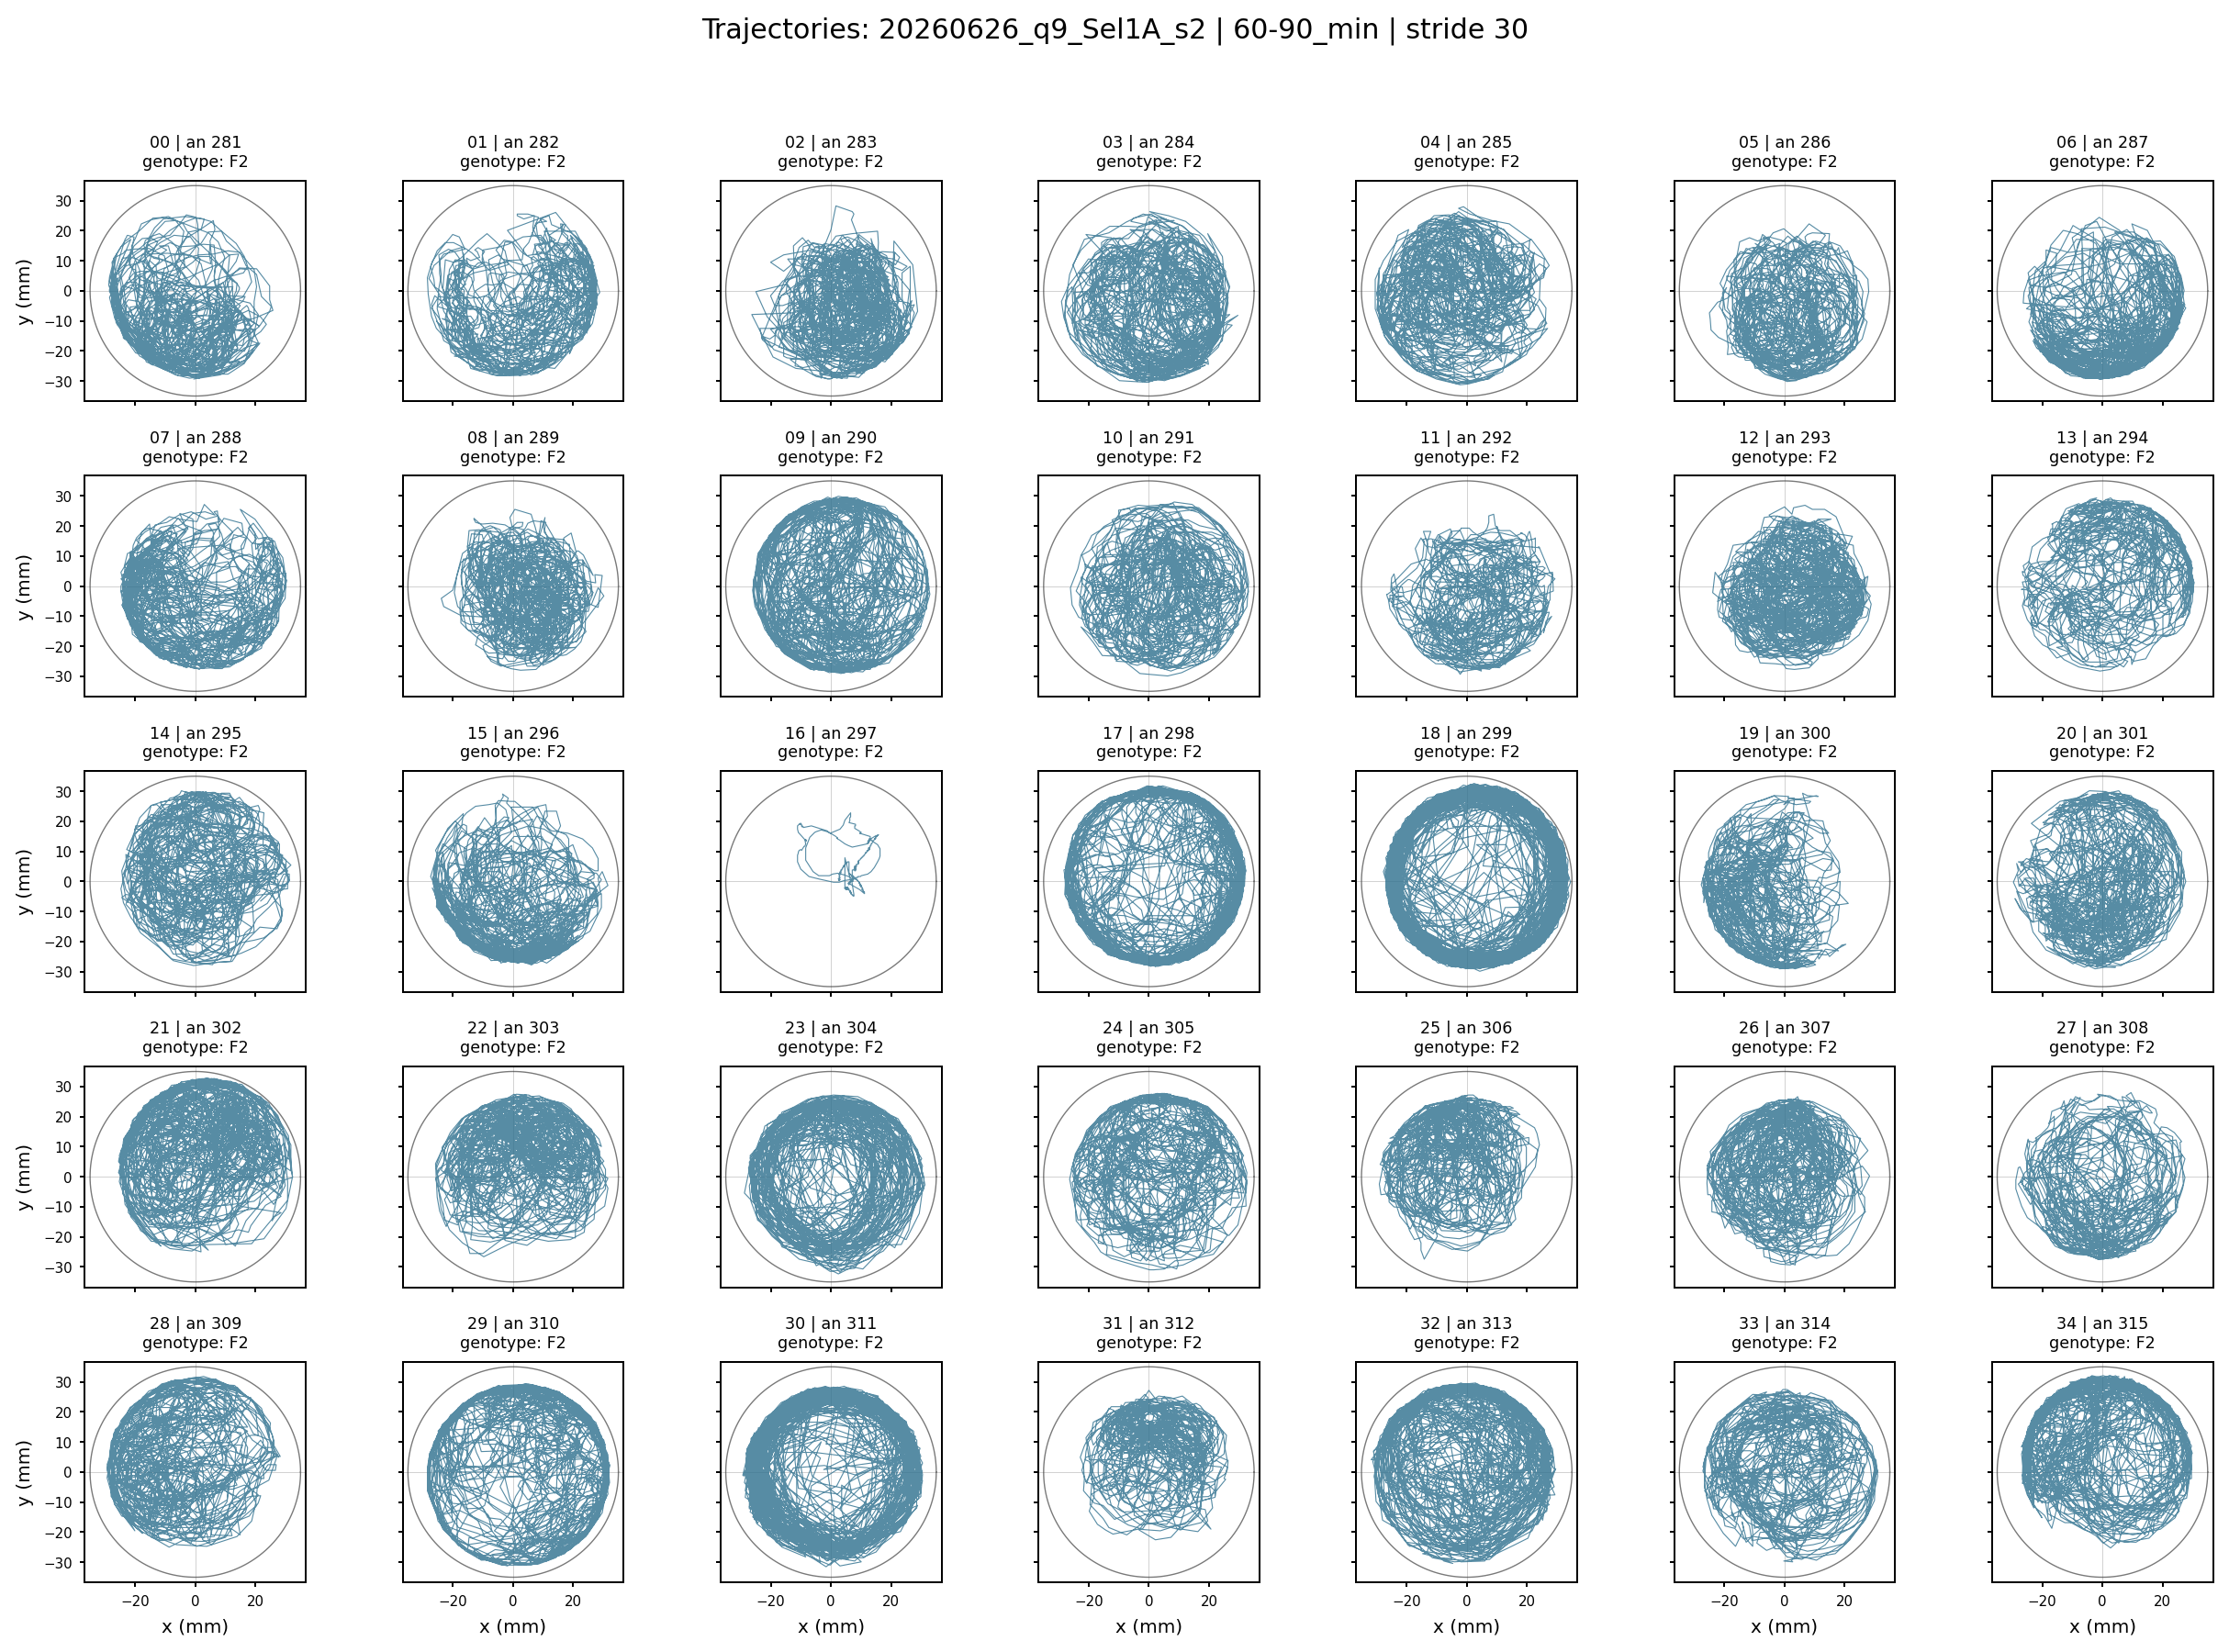

In [5]:
# Draw one trajectory subplot per fish. The notebook expects a 35-fish
# experiment, arranged as 5 rows by 7 columns for fast visual screening.
n_fish = xy_mm.shape[1]
n_rows, n_cols = 5, 7
if n_fish != n_rows * n_cols:
    raise ValueError(f'Expected {n_rows * n_cols} fish for a 5x7 grid, got {n_fish}.')
if len(animal_genotypes) != n_fish:
    raise ValueError(f'Expected {n_fish} genotype labels, got {len(animal_genotypes)}.')

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10), sharex=True, sharey=True, dpi=FIGURE_DPI)

# Use the same x/y range for every subplot so fish can be compared directly.
# The arena radius anchors the scale, and the trajectory percentile avoids one
# rare tracking jump creating a huge empty plot range.
limit = max(arena_radius_mm * 1.05, float(np.nanpercentile(np.abs(xy_mm), 99.5)) * 1.02)
theta = np.linspace(0, 2 * np.pi, 181)
circle_x = arena_radius_mm * np.cos(theta)
circle_y = arena_radius_mm * np.sin(theta)

for fish_idx, ax in enumerate(axes.ravel()):
    xy = xy_mm[:, fish_idx, :]
    ax.plot(xy[:, 0], xy[:, 1], color='#2D6F8E', lw=0.45, alpha=0.8, rasterized=True)
    ax.plot(circle_x, circle_y, color='0.25', lw=0.55, alpha=0.7)
    ax.axhline(0, color='0.8', lw=0.35, zorder=0)
    ax.axvline(0, color='0.8', lw=0.35, zorder=0)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal', adjustable='box')

    # The title carries the local fish index, true animal ID, and genotype so
    # unusual trajectories can be traced back to the metadata table.
    genotype = str(animal_genotypes[fish_idx]).strip() or 'unknown'
    ax.set_title(f'{fish_idx:02d} | an {animal_ids[fish_idx]}\ngenotype: {genotype}', fontsize=7)
    ax.tick_params(labelsize=6, length=2)

for ax in axes[-1, :]:
    ax.set_xlabel('x (mm)', fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel('y (mm)', fontsize=8)

folder = trajectory_meta.get('folder') or trajectory_meta.get('txt_stem', '')
fig.suptitle(
    f'Trajectories: {folder} | {trajectory_meta.get("window_label", "window")} | stride {trajectory_meta.get("frame_stride")}',
    fontsize=12,
    y=0.995,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])

output_base = os.path.join(
    OUTPUT_DIR,
    safe_filename(f'trajectory_grid_{folder}_{trajectory_meta.get("window_label", "window")}')
)
if SAVE_FIGURES:
    fig.savefig(output_base + '.png', dpi=FIGURE_DPI, bbox_inches='tight')
    fig.savefig(output_base + '.pdf', bbox_inches='tight')
    print('Wrote:', output_base + '.png')
    print('Wrote:', output_base + '.pdf')
plt.show()


## Plot 5x7 Movement Heatmap Grid

This grid converts each fish's sampled trajectory into an absolute time-occupancy heatmap. Each finite sampled x/y position contributes one sampled interval, in seconds, to its spatial bin. The speed labels and outlier table still use frame-to-frame distance, and the table below is sorted by `movement_z_mad_abs`, so the strongest movement outliers appear first regardless of whether they moved much more or much less than the cohort median.

`movement_z_mad` is a robust MAD z-score for `distance_per_min`: `0.6745 * (fish_mm_per_min - cohort_median_mm_per_min) / MAD`. Positive values are more active than the median fish in this plotted window; negative values are less active. `movement_z_mad_abs` is the absolute value used only for ranking potential outliers.

In [6]:
# Build the heatmap arrays and movement metrics table.
# Each finite sampled x/y position contributes one sample interval to the bin
# containing that position. The plot cell below shows where each fish spent time; speed
# metrics below still come from frame-to-frame distance.
n_fish = xy_mm.shape[1]
n_rows, n_cols = 5, 7
if n_fish != n_rows * n_cols:
    raise ValueError(f'Expected {n_rows * n_cols} fish for a 5x7 grid, got {n_fish}.')
if len(animal_genotypes) != n_fish:
    raise ValueError(f'Expected {n_fish} genotype labels, got {len(animal_genotypes)}.')

bins = MOVEMENT_HEATMAP_BINS
cmap = MOVEMENT_HEATMAP_CMAP
vmax_percentile = 90

# Use one square extent for every fish. This keeps the grid comparable and masks
# bins outside the circular arena so they draw as blank background.
limit = max(arena_radius_mm * 1.05, float(np.nanpercentile(np.abs(xy_mm), 99.5)) * 1.02)
edges = np.linspace(-limit, limit, bins + 1)
centers = (edges[:-1] + edges[1:]) / 2
grid_x, grid_y = np.meshgrid(centers, centers)
inside_arena = (grid_x ** 2 + grid_y ** 2) <= arena_radius_mm ** 2
extent = [-limit, limit, -limit, limit]
sample_seconds = float(trajectory_meta.get('frame_stride', FRAME_STRIDE)) / float(trajectory_meta.get('fps', FPS))

heatmaps = np.full((n_fish, bins, bins), np.nan)
metric_rows = []
for fish_idx in range(n_fish):
    xy = xy_mm[:, fish_idx, :]
    valid_positions = np.isfinite(xy).all(axis=1)

    # Consecutive sampled positions define one movement step for speed metrics.
    # The heatmap itself uses sampled-position occupancy time.
    steps = xy[1:] - xy[:-1]
    step_midpoints = (xy[1:] + xy[:-1]) / 2
    step_distance = np.sqrt(np.sum(steps ** 2, axis=1))
    valid_steps = np.isfinite(step_midpoints).all(axis=1) & np.isfinite(step_distance)
    valid_steps &= step_distance > 0

    position_weights = np.full(int(valid_positions.sum()), sample_seconds)
    hist, _, _ = np.histogram2d(
        xy[valid_positions, 0],
        xy[valid_positions, 1],
        bins=[edges, edges],
        weights=position_weights,
    )
    heatmap = hist.T
    heatmap[~inside_arena] = np.nan
    heatmaps[fish_idx] = heatmap

    total_distance_mm = float(np.nansum(step_distance[valid_steps]))
    valid_duration_min = float(valid_steps.sum() * sample_seconds / 60)
    distance_per_min = total_distance_mm / valid_duration_min if valid_duration_min > 0 else np.nan
    mean_speed_mm_s = total_distance_mm / (valid_duration_min * 60) if valid_duration_min > 0 else np.nan
    arena_coverage_fraction = float(np.count_nonzero(np.nan_to_num(heatmap) > 0) / inside_arena.sum())

    metric_rows.append({
        'fish_idx': fish_idx,
        'animal_id': animal_ids[fish_idx],
        'genotype': str(animal_genotypes[fish_idx]).strip() or 'unknown',
        'valid_samples': int(valid_positions.sum()),
        'valid_intervals': int(valid_steps.sum()),
        'valid_duration_min': valid_duration_min,
        'total_distance_mm': total_distance_mm,
        'distance_per_min': distance_per_min,
        'mean_speed_mm_s': mean_speed_mm_s,
        'arena_coverage_fraction': arena_coverage_fraction,
    })

movement_metrics = pd.DataFrame(metric_rows)

# Robust z-score: compare every fish's mm/min movement rate to the cohort median.
# MAD is less distorted by one extreme fish than a standard deviation would be.
movement_values = pd.Series(movement_metrics['distance_per_min'], dtype='float64')
movement_median = movement_values.median(skipna=True)
movement_mad = (movement_values - movement_median).abs().median(skipna=True)
if pd.isna(movement_mad) or movement_mad == 0:
    movement_metrics['movement_z_mad'] = 0.0
else:
    movement_metrics['movement_z_mad'] = 0.6745 * (movement_values - movement_median) / movement_mad
movement_metrics['movement_z_mad_abs'] = movement_metrics['movement_z_mad'].abs()



## Per-Fish Arena-Use Evenness

This screening metric scores each fish only inside its own observed occupancy radius. The personal radius excludes the unreachable outer ring from the evenness calculation, while the radius itself is kept and flagged separately so unusually restricted or unusually broad arena use is still visible.

In [7]:
# Compute per-fish arena-use evenness inside each fish's personal occupancy radius.
# This cell expects the movement heatmap cell above to have generated heatmaps,
# movement_metrics, grid_x, grid_y, inside_arena, extent, and xy_mm.
required_evenness_columns = {'fish_idx', 'animal_id', 'genotype'}
missing_evenness_columns = required_evenness_columns - set(movement_metrics.columns)
if missing_evenness_columns:
    raise ValueError('movement_metrics is missing columns: ' + ', '.join(sorted(missing_evenness_columns)))

required_evenness_vars = ['heatmaps', 'grid_x', 'grid_y', 'inside_arena', 'xy_mm', 'arena_radius_mm']
missing_evenness_vars = [name for name in required_evenness_vars if name not in globals()]
if missing_evenness_vars:
    raise ValueError('Run the movement heatmap cell first; missing: ' + ', '.join(missing_evenness_vars))

def _robust_z_mad(values):
    values = pd.Series(values, dtype='float64')
    median = values.median(skipna=True)
    mad = (values - median).abs().median(skipna=True)
    if pd.isna(mad) or mad == 0:
        return pd.Series(np.where(values.notna(), 0.0, np.nan), index=values.index, dtype='float64')
    return 0.6745 * (values - median) / mad

def _normalized_shannon_evenness(bin_seconds, reachable_bin_count):
    values = np.asarray(bin_seconds, dtype='float64')
    values = values[np.isfinite(values) & (values > 0)]
    total = values.sum()
    if reachable_bin_count <= 1 or total <= 0 or values.size == 0:
        return np.nan
    probabilities = values / total
    entropy = -np.sum(probabilities * np.log(probabilities))
    return float(entropy / np.log(reachable_bin_count))

# Tiny smoke check for the entropy normalization used below.
if not _normalized_shannon_evenness([1, 0, 0, 0], 4) < 1e-12:
    raise AssertionError('Single-bin occupancy should have near-zero evenness.')
if not np.isclose(_normalized_shannon_evenness([1, 1, 1, 1], 4), 1.0):
    raise AssertionError('Uniform occupancy should have evenness near one.')

n_fish = xy_mm.shape[1]
grid_radius = np.sqrt(grid_x ** 2 + grid_y ** 2)
grid_x_centers = np.unique(grid_x[0, :])
grid_y_centers = np.unique(grid_y[:, 0])
grid_dx = float(np.nanmedian(np.diff(grid_x_centers))) if grid_x_centers.size > 1 else 0.0
grid_dy = float(np.nanmedian(np.diff(grid_y_centers))) if grid_y_centers.size > 1 else 0.0
grid_half_diagonal = 0.5 * np.sqrt(grid_dx ** 2 + grid_dy ** 2)
personal_reachable_masks = np.zeros_like(heatmaps, dtype=bool)
evenness_rows = []

for fish_idx in range(n_fish):
    xy = xy_mm[:, fish_idx, :]
    radial_distance = np.sqrt(np.sum(xy ** 2, axis=1))
    valid_radius = np.isfinite(radial_distance) & (radial_distance <= arena_radius_mm)

    if valid_radius.any():
        personal_radius = float(np.nanpercentile(radial_distance[valid_radius], ARENA_OCCUPANCY_RADIUS_PERCENTILE))
        personal_radius = min(personal_radius, float(arena_radius_mm))
    else:
        personal_radius = np.nan

    if np.isfinite(personal_radius) and personal_radius > 0:
        # Include bins whose square overlaps the personal-radius circle. This
        # avoids an empty mask for strongly center-confined fish at coarse binning.
        reachable_mask = inside_arena & (grid_radius <= personal_radius + grid_half_diagonal)
    else:
        reachable_mask = np.zeros_like(inside_arena, dtype=bool)
    personal_reachable_masks[fish_idx] = reachable_mask

    heatmap = heatmaps[fish_idx]
    reachable_seconds = heatmap[reachable_mask]
    positive_reachable_seconds = reachable_seconds[np.isfinite(reachable_seconds) & (reachable_seconds > 0)]
    reachable_bin_count = int(reachable_mask.sum())
    visited_reachable_bin_count = int(positive_reachable_seconds.size)
    total_reachable_seconds = float(positive_reachable_seconds.sum()) if positive_reachable_seconds.size else 0.0
    evenness = _normalized_shannon_evenness(positive_reachable_seconds, reachable_bin_count)
    coverage = visited_reachable_bin_count / reachable_bin_count if reachable_bin_count > 0 else np.nan

    evenness_rows.append({
        'fish_idx': fish_idx,
        'personal_occupancy_radius_mm': personal_radius,
        'reachable_bin_count': reachable_bin_count,
        'visited_reachable_bin_count': visited_reachable_bin_count,
        'total_reachable_seconds': total_reachable_seconds,
        'arena_evenness_shannon': evenness,
        'arena_bias_index': 1 - evenness if np.isfinite(evenness) else np.nan,
        'reachable_coverage_fraction': coverage,
    })

arena_evenness = pd.DataFrame(evenness_rows)
arena_evenness['arena_evenness_z_mad'] = _robust_z_mad(arena_evenness['arena_evenness_shannon'])
arena_evenness['low_arena_evenness_flag'] = arena_evenness['arena_evenness_z_mad'] <= -ARENA_EVENNESS_ZMAD_THRESHOLD
arena_evenness['occupancy_radius_z_mad'] = _robust_z_mad(arena_evenness['personal_occupancy_radius_mm'])
arena_evenness['occupancy_radius_z_mad_abs'] = arena_evenness['occupancy_radius_z_mad'].abs()
arena_evenness['occupancy_radius_outlier_flag'] = arena_evenness['occupancy_radius_z_mad_abs'] >= ARENA_RADIUS_ZMAD_THRESHOLD
arena_evenness['low_occupancy_radius_flag'] = arena_evenness['occupancy_radius_z_mad'] <= -ARENA_RADIUS_ZMAD_THRESHOLD
arena_evenness['high_occupancy_radius_flag'] = arena_evenness['occupancy_radius_z_mad'] >= ARENA_RADIUS_ZMAD_THRESHOLD

if (arena_evenness['personal_occupancy_radius_mm'] > arena_radius_mm + 1e-9).any():
    raise AssertionError('Personal occupancy radius exceeded arena_radius_mm.')

finite_radius_count = arena_evenness['personal_occupancy_radius_mm'].nunique(dropna=True)
unique_personal_mask_count = len({personal_reachable_masks[i].tobytes() for i in range(n_fish)})
if finite_radius_count > 1 and unique_personal_mask_count <= 1:
    warnings.warn('Personal radii differ, but the reachable masks are identical at this heatmap resolution.')

evenness_columns = [
    'personal_occupancy_radius_mm',
    'reachable_bin_count',
    'visited_reachable_bin_count',
    'total_reachable_seconds',
    'arena_evenness_shannon',
    'arena_bias_index',
    'reachable_coverage_fraction',
    'arena_evenness_z_mad',
    'low_arena_evenness_flag',
    'occupancy_radius_z_mad',
    'occupancy_radius_z_mad_abs',
    'occupancy_radius_outlier_flag',
    'low_occupancy_radius_flag',
    'high_occupancy_radius_flag',
]
movement_metrics = movement_metrics.drop(
    columns=[column for column in evenness_columns if column in movement_metrics.columns],
    errors='ignore',
).merge(arena_evenness[['fish_idx'] + evenness_columns], on='fish_idx', how='left')

arena_evenness_screen = movement_metrics.copy()
arena_evenness_screen = arena_evenness_screen.sort_values(
    ['low_arena_evenness_flag', 'occupancy_radius_outlier_flag', 'arena_evenness_z_mad', 'occupancy_radius_z_mad_abs'],
    ascending=[False, False, True, False],
).reset_index(drop=True)

folder = trajectory_meta.get('folder') or trajectory_meta.get('txt_stem', '')
evenness_output_base = os.path.join(
    OUTPUT_DIR,
    safe_filename(f'movement_heatmap_grid_{folder}_{trajectory_meta.get("window_label", "window")}')
)
if SAVE_FIGURES:
    evenness_csv = evenness_output_base + '_arena_evenness.csv'
    movement_metrics.to_csv(evenness_csv, index=False)
    print('Wrote:', evenness_csv)

print('Personal occupancy radius percentile:', ARENA_OCCUPANCY_RADIUS_PERCENTILE)
print('Unique personal reachable masks:', unique_personal_mask_count)
print('Low arena-evenness flags:', int(arena_evenness['low_arena_evenness_flag'].sum()))
print('Occupancy-radius outlier flags:', int(arena_evenness['occupancy_radius_outlier_flag'].sum()))

display_columns = [
    'fish_idx',
    'animal_id',
    'genotype',
    'arena_evenness_shannon',
    'arena_bias_index',
    'arena_evenness_z_mad',
    'low_arena_evenness_flag',
    'personal_occupancy_radius_mm',
    'occupancy_radius_z_mad',
    'occupancy_radius_outlier_flag',
    'low_occupancy_radius_flag',
    'high_occupancy_radius_flag',
    'reachable_coverage_fraction',
    'reachable_bin_count',
    'visited_reachable_bin_count',
]
display(arena_evenness_screen[display_columns])


Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/movement_heatmap_grid_20260626_q9_Sel1A_s2_60-90_min_arena_evenness.csv
Personal occupancy radius percentile: 99.5
Unique personal reachable masks: 30
Low arena-evenness flags: 4
Occupancy-radius outlier flags: 3


,fish_idx,animal_id,genotype,arena_evenness_shannon,arena_bias_index,arena_evenness_z_mad,low_arena_evenness_flag,personal_occupancy_radius_mm,occupancy_radius_z_mad,occupancy_radius_outlier_flag,low_occupancy_radius_flag,high_occupancy_radius_flag,reachable_coverage_fraction,reachable_bin_count,visited_reachable_bin_count
0,16,297,F2,0.514343,0.485657,-34.294600,True,21.879237,-4.349687,True,True,False,0.074310,1884,140
1,18,299,F2,0.810428,0.189572,-4.521598,True,34.221201,1.921984,True,False,True,0.239188,4532,1084
2,17,298,F2,0.832187,0.167813,-2.333660,True,32.840688,1.220465,False,False,False,0.283173,4160,1178
3,6,287,F2,0.834892,0.165108,-2.061593,True,29.352635,-0.552018,False,False,False,0.311534,3364,1048
4,21,302,F2,0.840839,0.159161,-1.463628,False,33.900471,1.759002,True,False,True,0.290656,4452,1294
5,30,311,F2,0.841628,0.158372,-1.384256,False,30.643160,0.103773,False,False,False,0.314419,3648,1147
6,34,315,F2,0.843618,0.156382,-1.184226,False,32.037487,0.812312,False,False,False,0.312312,3980,1243
7,31,312,F2,0.843919,0.156081,-1.153953,False,27.732903,-1.375098,False,False,False,0.343000,3000,1029
8,25,306,F2,0.847111,0.152889,-0.832920,False,28.364321,-1.054238,False,False,False,0.348852,3136,1094
9,29,310,F2,0.847283,0.152717,-0.815638,False,32.109890,0.849104,False,False,False,0.317067,3996,1267


Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/movement_heatmap_grid_20260626_q9_Sel1A_s2_60-90_min.png
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/movement_heatmap_grid_20260626_q9_Sel1A_s2_60-90_min.pdf
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/movement_heatmap_grid_20260626_q9_Sel1A_s2_60-90_min_metrics.csv


,fish_idx,animal_id,genotype,valid_samples,valid_intervals,valid_duration_min,total_distance_mm,distance_per_min,mean_speed_mm_s,arena_coverage_fraction,...,arena_evenness_shannon,arena_bias_index,reachable_coverage_fraction,arena_evenness_z_mad,low_arena_evenness_flag,occupancy_radius_z_mad,occupancy_radius_z_mad_abs,occupancy_radius_outlier_flag,low_occupancy_radius_flag,high_occupancy_radius_flag
0,18,299,F2,1800,1799,29.983333,24806.940700,827.357666,13.789294,0.237928,...,0.810428,0.189572,0.239188,-4.521598,True,1.921984,1.921984,True,False,True
1,30,311,F2,1800,1797,29.950000,19766.277726,659.975884,10.999598,0.252634,...,0.841628,0.158372,0.314419,-1.384256,False,0.103773,0.103773,False,False,False
2,16,297,F2,1800,659,10.983333,341.775221,31.117623,0.518627,0.031168,...,0.514343,0.485657,0.074310,-34.294600,True,-4.349687,4.349687,True,True,False
3,32,313,F2,1800,1799,29.983333,13800.767664,460.281301,7.671355,0.295215,...,0.863245,0.136755,0.356915,0.789391,False,0.370791,0.370791,False,False,False
4,23,304,F2,1800,1799,29.983333,12557.880401,418.828696,6.980478,0.289289,...,0.857483,0.142517,0.342544,0.209988,False,0.468712,0.468712,False,False,False
5,21,302,F2,1800,1799,29.983333,12337.456937,411.477163,6.857953,0.284021,...,0.840839,0.159161,0.290656,-1.463628,False,1.759002,1.759002,True,False,True
6,17,298,F2,1800,1799,29.983333,12238.263267,408.168869,6.802814,0.258780,...,0.832187,0.167813,0.283173,-2.333660,True,1.220465,1.220465,False,False,False
7,9,290,F2,1800,1799,29.983333,11859.756135,395.544952,6.592416,0.294996,...,0.855213,0.144787,0.328523,-0.018235,False,1.045941,1.045941,False,False,False
8,11,292,F2,1800,1757,29.283333,6171.812967,210.761968,3.512699,0.253731,...,0.855394,0.144606,0.353121,0.000000,False,-0.711187,0.711187,False,False,False
9,31,312,F2,1800,1788,29.800000,6404.678748,214.922106,3.582035,0.226295,...,0.843919,0.156081,0.343000,-1.153953,False,-1.375098,1.375098,False,False,False


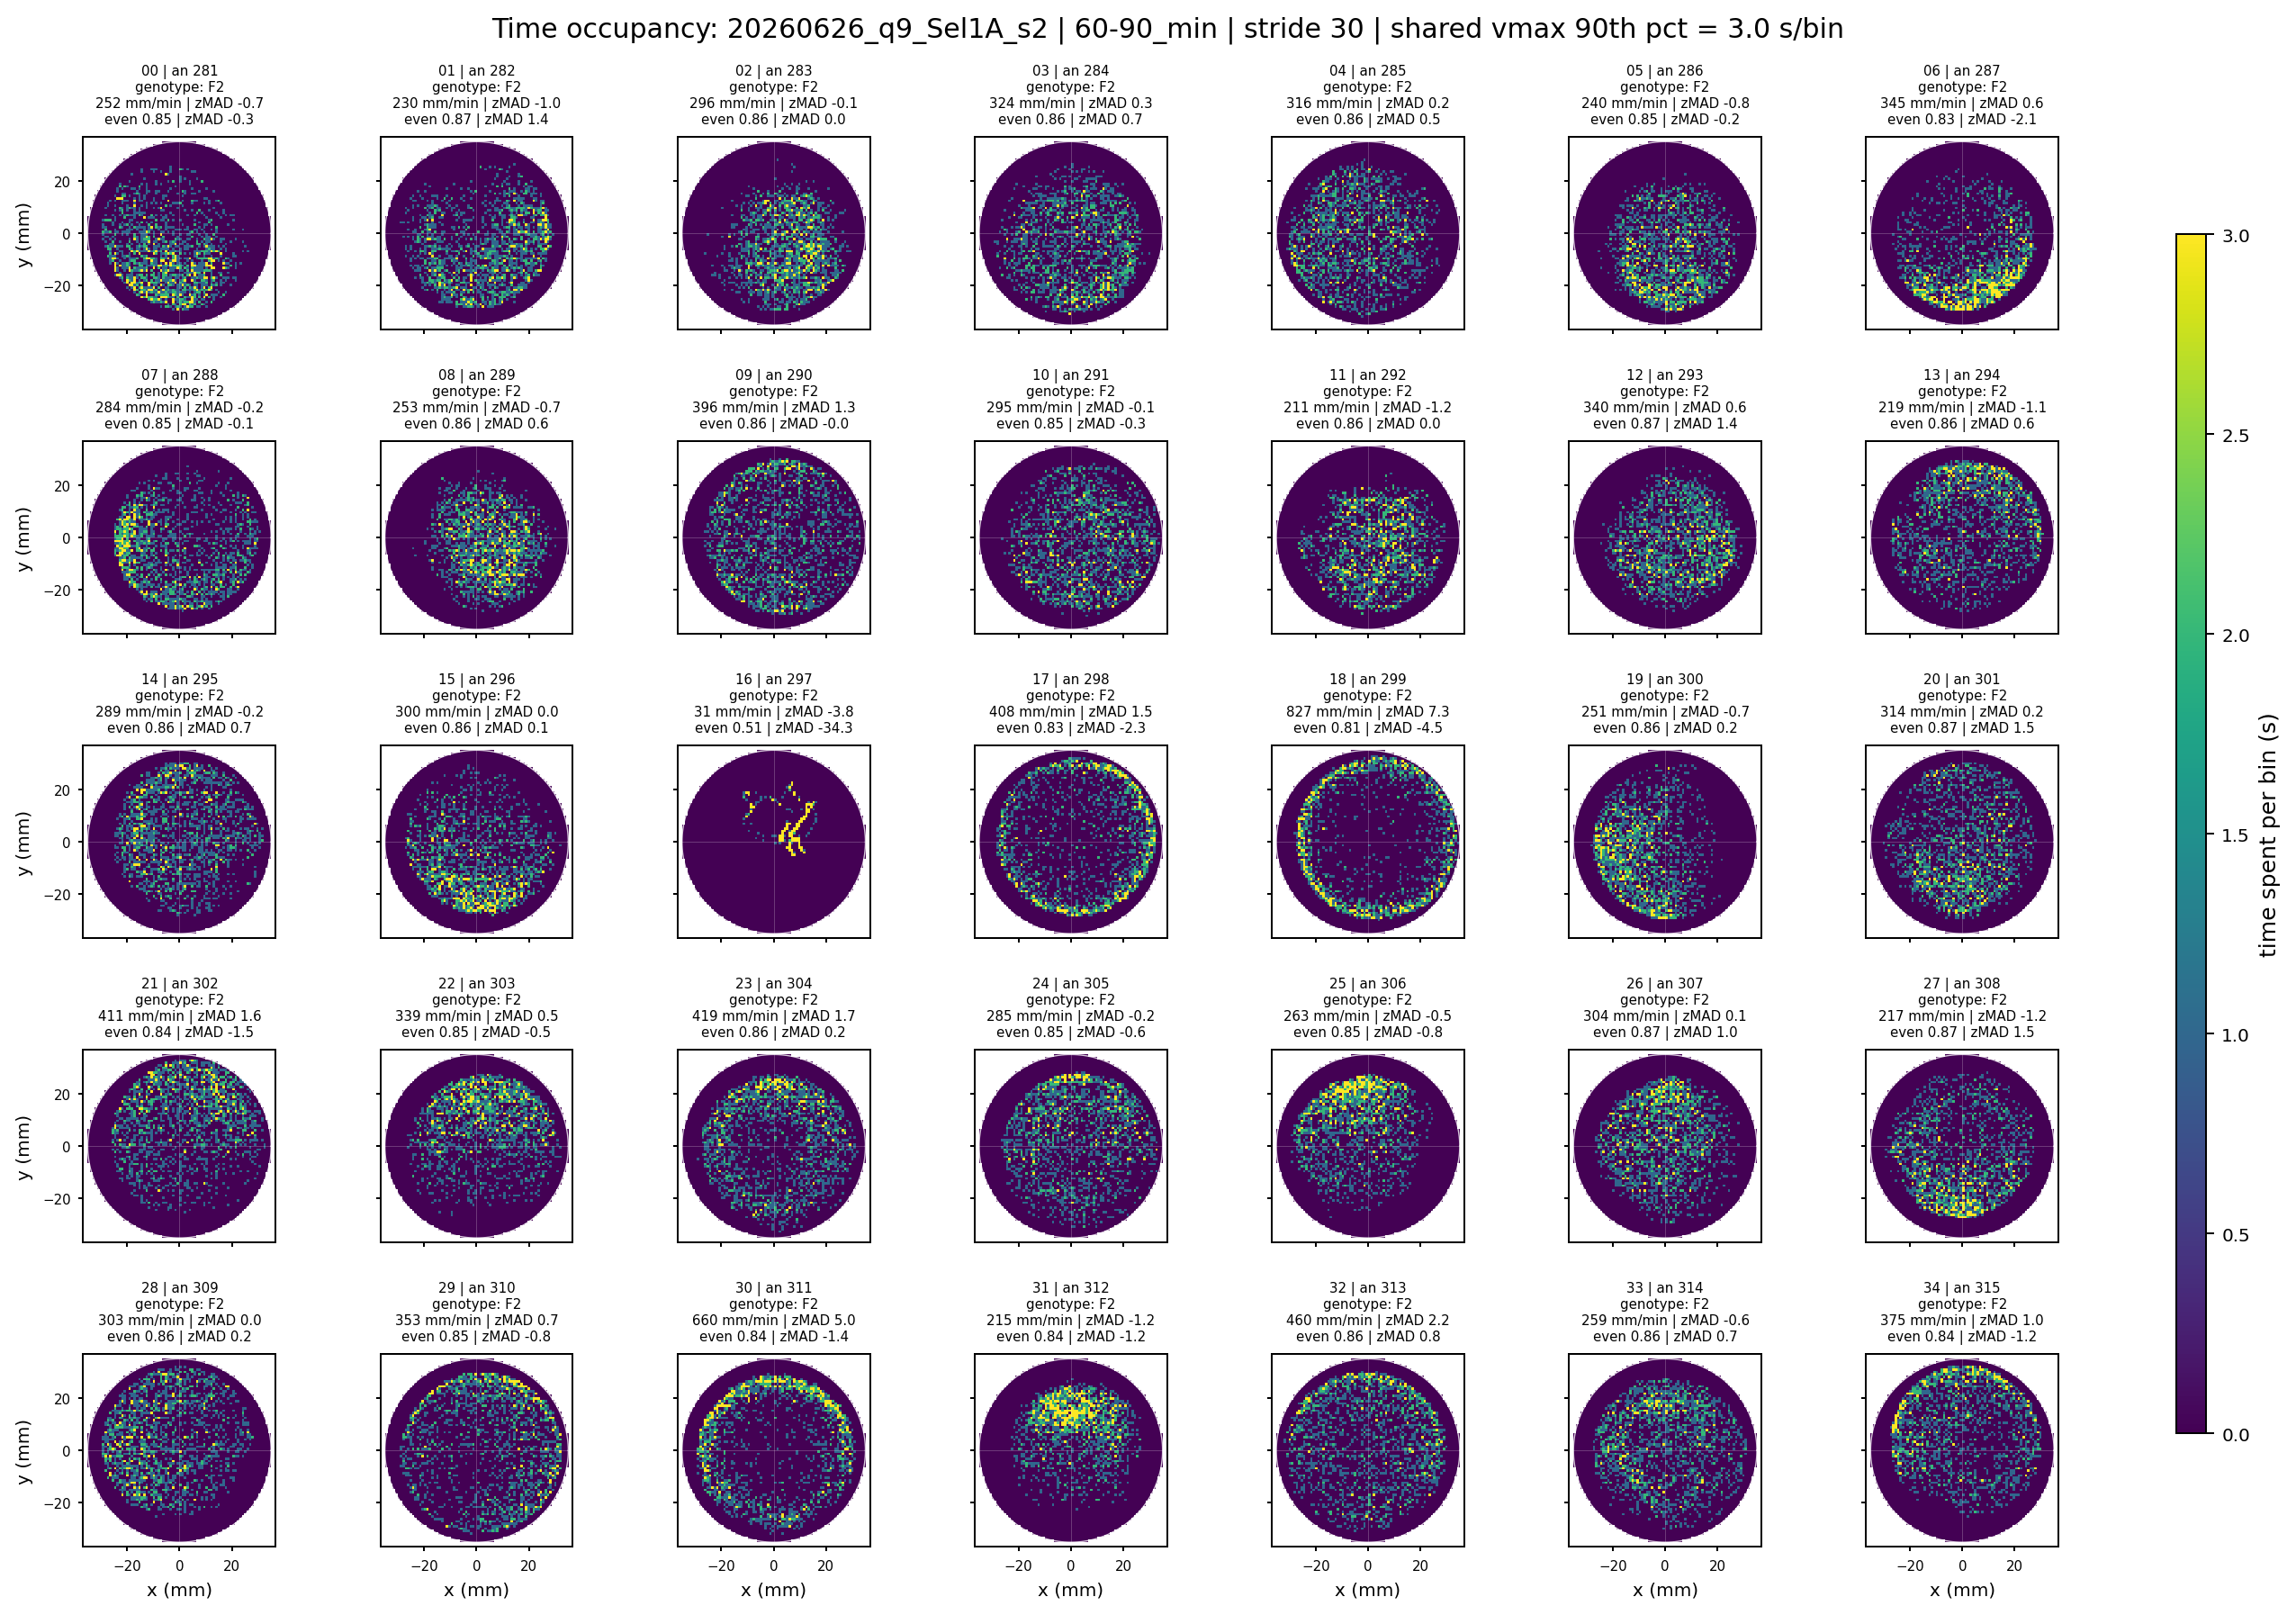

In [8]:
# Plot the 5x7 heatmap grid after arena-use evenness has been added to movement_metrics.
required_heatmap_label_columns = {
    'fish_idx',
    'animal_id',
    'genotype',
    'distance_per_min',
    'movement_z_mad',
    'arena_evenness_shannon',
    'arena_evenness_z_mad',
}
missing_heatmap_label_columns = required_heatmap_label_columns - set(movement_metrics.columns)
if missing_heatmap_label_columns:
    raise ValueError('movement_metrics is missing columns: ' + ', '.join(sorted(missing_heatmap_label_columns)))

# Pick one color scale for all 35 heatmaps, using only positive in-arena bins.
# This makes bright panels comparable across fish without one extreme bin washing
# out the rest of the experiment.
positive_values = heatmaps[np.isfinite(heatmaps) & (heatmaps > 0)]
vmax = float(np.nanpercentile(positive_values, vmax_percentile)) if positive_values.size else 1.0
if not np.isfinite(vmax) or vmax <= 0:
    vmax = 1.0

heatmap_fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True, sharey=True, dpi=FIGURE_DPI)
theta = np.linspace(0, 2 * np.pi, 181)
circle_x = arena_radius_mm * np.cos(theta)
circle_y = arena_radius_mm * np.sin(theta)
im = None

for fish_idx, ax in enumerate(axes.ravel()):
    im = ax.imshow(
        np.ma.masked_invalid(heatmaps[fish_idx]),
        origin='lower',
        extent=extent,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        interpolation='nearest',
        rasterized=True,
    )
    ax.plot(circle_x, circle_y, color='white', lw=0.55, alpha=0.8)
    ax.axhline(0, color='white', lw=0.25, alpha=0.35, zorder=2)
    ax.axvline(0, color='white', lw=0.25, alpha=0.35, zorder=2)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect('equal', adjustable='box')

    # The title repeats the most useful screening numbers: movement rate and
    # robust deviation from the cohort median.
    row = movement_metrics.iloc[fish_idx]
    ax.set_title(
        f'{fish_idx:02d} | an {row["animal_id"]}\n'
        f'genotype: {row["genotype"]}\n'
        f'{row["distance_per_min"]:.0f} mm/min | zMAD {row["movement_z_mad"]:.1f}\n'
        f'even {row["arena_evenness_shannon"]:.2f} | zMAD {row["arena_evenness_z_mad"]:.1f}',
        fontsize=6.0,
    )
    ax.tick_params(labelsize=6, length=2)

for ax in axes[-1, :]:
    ax.set_xlabel('x (mm)', fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel('y (mm)', fontsize=8)

folder = trajectory_meta.get('folder') or trajectory_meta.get('txt_stem', '')
heatmap_fig.suptitle(
    f'Time occupancy: {folder} | {trajectory_meta.get("window_label", "window")} | '
    f'stride {trajectory_meta.get("frame_stride")} | shared vmax {vmax_percentile:g}th pct = {vmax:.1f} s/bin',
    fontsize=12,
    y=0.995,
)
heatmap_fig.subplots_adjust(left=0.04, right=0.88, bottom=0.05, top=0.92, wspace=0.15, hspace=0.58)

# Put the shared colorbar in a fixed outer axis so it does not steal space from
# the rightmost subplots.
cbar_ax = heatmap_fig.add_axes([0.915, 0.12, 0.012, 0.74])
cbar = heatmap_fig.colorbar(im, cax=cbar_ax, label='time spent per bin (s)')
cbar.ax.tick_params(labelsize=8)

output_base = os.path.join(
    OUTPUT_DIR,
    safe_filename(f'movement_heatmap_grid_{folder}_{trajectory_meta.get("window_label", "window")}')
)
if SAVE_FIGURES:
    heatmap_fig.savefig(output_base + '.png', dpi=FIGURE_DPI, bbox_inches='tight')
    heatmap_fig.savefig(output_base + '.pdf', bbox_inches='tight')
    movement_metrics.to_csv(output_base + '_metrics.csv', index=False)
    print('Wrote:', output_base + '.png')
    print('Wrote:', output_base + '.pdf')
    print('Wrote:', output_base + '_metrics.csv')

# Sort by absolute robust deviation so both very high movement and very low
# movement fish rise to the top for manual screening.
# Column meanings:
# - fish_idx: local subplot index in the 5x7 grid.
# - animal_id and genotype: metadata labels for the plotted fish.
# - valid_samples: finite x/y positions that contributed to time-occupancy heatmap bins.
# - valid_intervals: finite nonzero steps used for distance and speed metrics.
# - valid_duration_min: valid_intervals converted to elapsed minutes.
# - total_distance_mm: summed valid step distance in the window.
# - distance_per_min and mean_speed_mm_s: movement rate in mm/min and mm/s.
# - arena_coverage_fraction: fraction of in-arena heatmap bins with any sampled occupancy.
# - movement_z_mad: robust cohort-centered z-score of distance_per_min.
# - movement_z_mad_abs: absolute zMAD used for this outlier ranking.
movement_outliers = movement_metrics.sort_values('movement_z_mad_abs', ascending=False).reset_index(drop=True)
display(movement_outliers)
plt.show()


Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/individual_speed_distribution_20260626_q9_Sel1A_s2_60-90_min.png
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/individual_speed_distribution_20260626_q9_Sel1A_s2_60-90_min.pdf
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/individual_speed_distribution_20260626_q9_Sel1A_s2_60-90_min_speed.csv


,fish_idx,animal_id,genotype,valid_samples,valid_intervals,valid_duration_min,total_distance_mm,distance_per_min,mean_speed_mm_s,arena_coverage_fraction,...,arena_evenness_shannon,arena_bias_index,reachable_coverage_fraction,arena_evenness_z_mad,low_arena_evenness_flag,occupancy_radius_z_mad,occupancy_radius_z_mad_abs,occupancy_radius_outlier_flag,low_occupancy_radius_flag,high_occupancy_radius_flag
0,18,299,F2,1800,1799,29.983333,24806.940700,827.357666,13.789294,0.237928,...,0.810428,0.189572,0.239188,-4.521598,True,1.921984,1.921984,True,False,True
1,30,311,F2,1800,1797,29.950000,19766.277726,659.975884,10.999598,0.252634,...,0.841628,0.158372,0.314419,-1.384256,False,0.103773,0.103773,False,False,False
2,32,313,F2,1800,1799,29.983333,13800.767664,460.281301,7.671355,0.295215,...,0.863245,0.136755,0.356915,0.789391,False,0.370791,0.370791,False,False,False
3,23,304,F2,1800,1799,29.983333,12557.880401,418.828696,6.980478,0.289289,...,0.857483,0.142517,0.342544,0.209988,False,0.468712,0.468712,False,False,False
4,21,302,F2,1800,1799,29.983333,12337.456937,411.477163,6.857953,0.284021,...,0.840839,0.159161,0.290656,-1.463628,False,1.759002,1.759002,True,False,True
5,17,298,F2,1800,1799,29.983333,12238.263267,408.168869,6.802814,0.258780,...,0.832187,0.167813,0.283173,-2.333660,True,1.220465,1.220465,False,False,False
6,9,290,F2,1800,1799,29.983333,11859.756135,395.544952,6.592416,0.294996,...,0.855213,0.144787,0.328523,-0.018235,False,1.045941,1.045941,False,False,False
7,34,315,F2,1800,1798,29.966667,11245.323144,375.261062,6.254351,0.272827,...,0.843618,0.156382,0.312312,-1.184226,False,0.812312,0.812312,False,False,False
8,29,310,F2,1800,1799,29.983333,10575.689151,352.718927,5.878649,0.278095,...,0.847283,0.152717,0.317067,-0.815638,False,0.849104,0.849104,False,False,False
9,6,287,F2,1800,1799,29.983333,10335.573372,344.710618,5.745177,0.230026,...,0.834892,0.165108,0.311534,-2.061593,True,-0.552018,0.552018,False,False,False


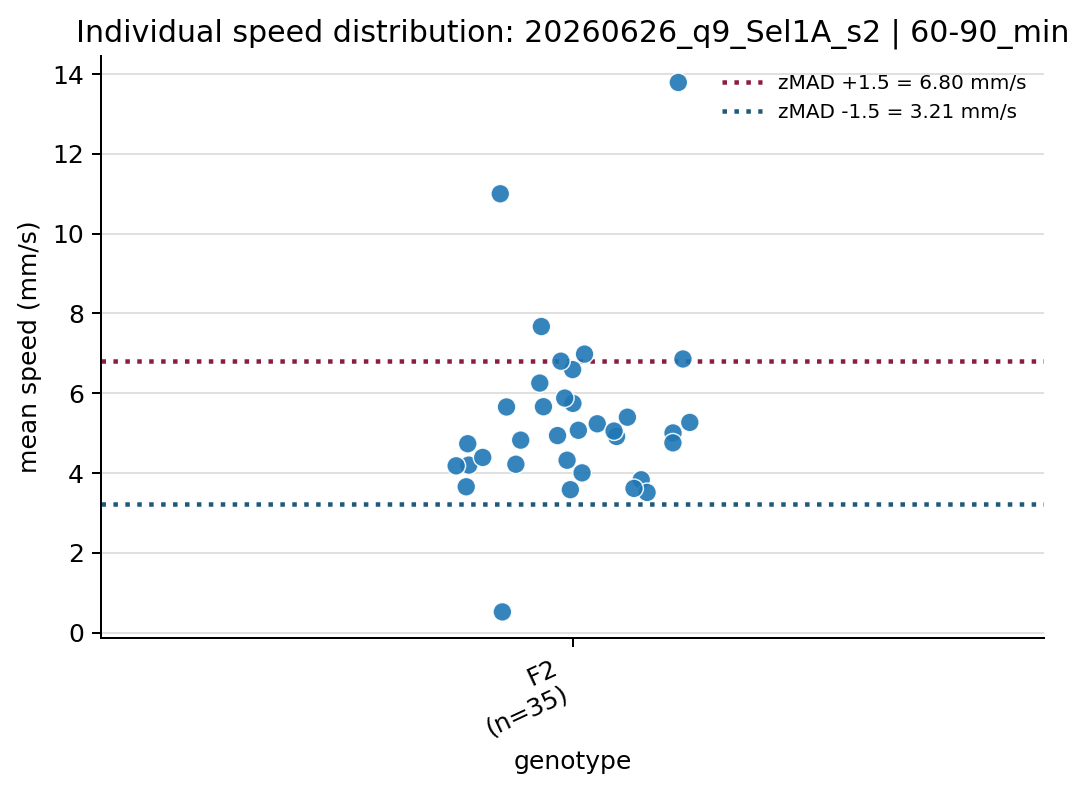

In [9]:
# Plot each fish's mean speed from the movement_metrics table generated above.
# The required columns check gives a clear error if the heatmap cell has not been
# run or if the metrics table structure changes later.
required_speed_columns = {'fish_idx', 'animal_id', 'genotype', 'distance_per_min', 'mean_speed_mm_s'}
missing_speed_columns = required_speed_columns - set(movement_metrics.columns)
if missing_speed_columns:
    raise ValueError('movement_metrics is missing columns: ' + ', '.join(sorted(missing_speed_columns)))

# Clean genotype labels before grouping so blank labels appear as a visible
# 'unknown' group instead of being silently dropped or merged with whitespace.
individual_speed = movement_metrics.copy()
individual_speed['genotype'] = individual_speed['genotype'].astype(str).str.strip().replace('', 'unknown')
individual_speed = individual_speed[np.isfinite(individual_speed['mean_speed_mm_s'])].copy()
genotype_order = sorted(individual_speed['genotype'].unique())
genotype_counts = individual_speed.groupby('genotype').size().reindex(genotype_order)
palette_name = 'tab10' if len(genotype_order) <= 10 else 'tab20'
genotype_colors = dict(zip(genotype_order, sns.color_palette(palette_name, n_colors=len(genotype_order))))

# Jitter separates fish with the same genotype so individual points remain visible.
# The fixed random seed makes the displayed plot stable across reruns.
np.random.seed(7)
fig_width = max(6, 1.2 * len(genotype_order) + 2)
fig, ax = plt.subplots(figsize=(fig_width, 4.5), dpi=FIGURE_DPI)

sns.stripplot(
    data=individual_speed,
    x='genotype',
    y='mean_speed_mm_s',
    hue='genotype',
    order=genotype_order,
    hue_order=genotype_order,
    palette=genotype_colors,
    jitter=0.13,
    size=7.5,
    edgecolor='white',
    linewidth=0.6,
    alpha=0.9,
    legend=False,
    ax=ax,
    zorder=3,
)

# Draw the mean-speed values corresponding to movement zMAD = +/-3.
# zMAD is defined on distance_per_min above, then converted here to mm/s.
speed_zmad_threshold = 1.5
movement_values_for_speed = pd.Series(individual_speed['distance_per_min'], dtype='float64')
movement_median_for_speed = movement_values_for_speed.median(skipna=True)
movement_mad_for_speed = (movement_values_for_speed - movement_median_for_speed).abs().median(skipna=True)
if not pd.isna(movement_mad_for_speed) and movement_mad_for_speed != 0:
    zmad_delta = speed_zmad_threshold * movement_mad_for_speed / 0.6745
    zmad_speed_lines = [
        (f'zMAD +{speed_zmad_threshold:g}', (movement_median_for_speed + zmad_delta) / 60, '#8B1E3F'),
        (f'zMAD -{speed_zmad_threshold:g}', (movement_median_for_speed - zmad_delta) / 60, '#1F5A7A'),
    ]
    for zmad_label, speed_threshold, line_color in zmad_speed_lines:
        if np.isfinite(speed_threshold):
            ax.axhline(
                speed_threshold,
                color=line_color,
                linestyle=':',
                linewidth=1.8,
                label=f'{zmad_label} = {speed_threshold:.2f} mm/s',
                zorder=2,
            )

ax.set_xticks(range(len(genotype_order)))
ax.set_xticklabels([f'{genotype}\n(n={genotype_counts[genotype]})' for genotype in genotype_order], rotation=25, ha='right')
ax.set_ylabel('mean speed (mm/s)')
ax.set_xlabel('genotype')
ax.set_title(
    f'Individual speed distribution: {trajectory_meta.get("folder") or trajectory_meta.get("txt_stem", "")}'
    f' | {trajectory_meta.get("window_label", "window")}'
)
ax.grid(axis='y', color='0.88', linewidth=0.8)
sns.despine(ax=ax)
ax.legend(frameon=False, loc='best', fontsize=8)
fig.tight_layout()

if SAVE_FIGURES:
    folder = trajectory_meta.get('folder') or trajectory_meta.get('txt_stem', '')
    output_base = os.path.join(
        OUTPUT_DIR,
        safe_filename(f'individual_speed_distribution_{folder}_{trajectory_meta.get("window_label", "window")}')
    )
    fig.savefig(output_base + '.png', dpi=FIGURE_DPI, bbox_inches='tight')
    fig.savefig(output_base + '.pdf', bbox_inches='tight')
    individual_speed.to_csv(output_base + '_speed.csv', index=False)
    print('Wrote:', output_base + '.png')
    print('Wrote:', output_base + '.pdf')
    print('Wrote:', output_base + '_speed.csv')

display(individual_speed.sort_values('mean_speed_mm_s', ascending=False).reset_index(drop=True))
plt.show()


## Plot Individual Arena-Use Metrics

These point plots mirror the speed distribution plot, but show arena-use evenness and personal occupancy radius across genotypes. Dotted lines mark the same robust zMAD thresholds used for the screening flags.

Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/individual_arena_evenness_distribution_20260626_q9_Sel1A_s2_60-90_min.png
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/individual_arena_evenness_distribution_20260626_q9_Sel1A_s2_60-90_min.pdf
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/individual_arena_evenness_distribution_20260626_q9_Sel1A_s2_60-90_min_arena_evenness_distribution.csv


,fish_idx,animal_id,genotype,valid_samples,valid_intervals,valid_duration_min,total_distance_mm,distance_per_min,mean_speed_mm_s,arena_coverage_fraction,...,arena_evenness_shannon,arena_bias_index,reachable_coverage_fraction,arena_evenness_z_mad,low_arena_evenness_flag,occupancy_radius_z_mad,occupancy_radius_z_mad_abs,occupancy_radius_outlier_flag,low_occupancy_radius_flag,high_occupancy_radius_flag
0,16,297,F2,1800,659,10.983333,341.775221,31.117623,0.518627,0.031168,...,0.514343,0.485657,0.074310,-34.294600,True,-4.349687,4.349687,True,True,False
1,18,299,F2,1800,1799,29.983333,24806.940700,827.357666,13.789294,0.237928,...,0.810428,0.189572,0.239188,-4.521598,True,1.921984,1.921984,True,False,True
2,17,298,F2,1800,1799,29.983333,12238.263267,408.168869,6.802814,0.258780,...,0.832187,0.167813,0.283173,-2.333660,True,1.220465,1.220465,False,False,False
3,6,287,F2,1800,1799,29.983333,10335.573372,344.710618,5.745177,0.230026,...,0.834892,0.165108,0.311534,-2.061593,True,-0.552018,0.552018,False,False,False
4,21,302,F2,1800,1799,29.983333,12337.456937,411.477163,6.857953,0.284021,...,0.840839,0.159161,0.290656,-1.463628,False,1.759002,1.759002,True,False,True
5,30,311,F2,1800,1797,29.950000,19766.277726,659.975884,10.999598,0.252634,...,0.841628,0.158372,0.314419,-1.384256,False,0.103773,0.103773,False,False,False
6,34,315,F2,1800,1798,29.966667,11245.323144,375.261062,6.254351,0.272827,...,0.843618,0.156382,0.312312,-1.184226,False,0.812312,0.812312,False,False,False
7,31,312,F2,1800,1788,29.800000,6404.678748,214.922106,3.582035,0.226295,...,0.843919,0.156081,0.343000,-1.153953,False,-1.375098,1.375098,False,False,False
8,25,306,F2,1800,1775,29.583333,7793.087517,263.428310,4.390472,0.241220,...,0.847111,0.152889,0.348852,-0.832920,False,-1.054238,1.054238,False,False,False
9,29,310,F2,1800,1799,29.983333,10575.689151,352.718927,5.878649,0.278095,...,0.847283,0.152717,0.317067,-0.815638,False,0.849104,0.849104,False,False,False


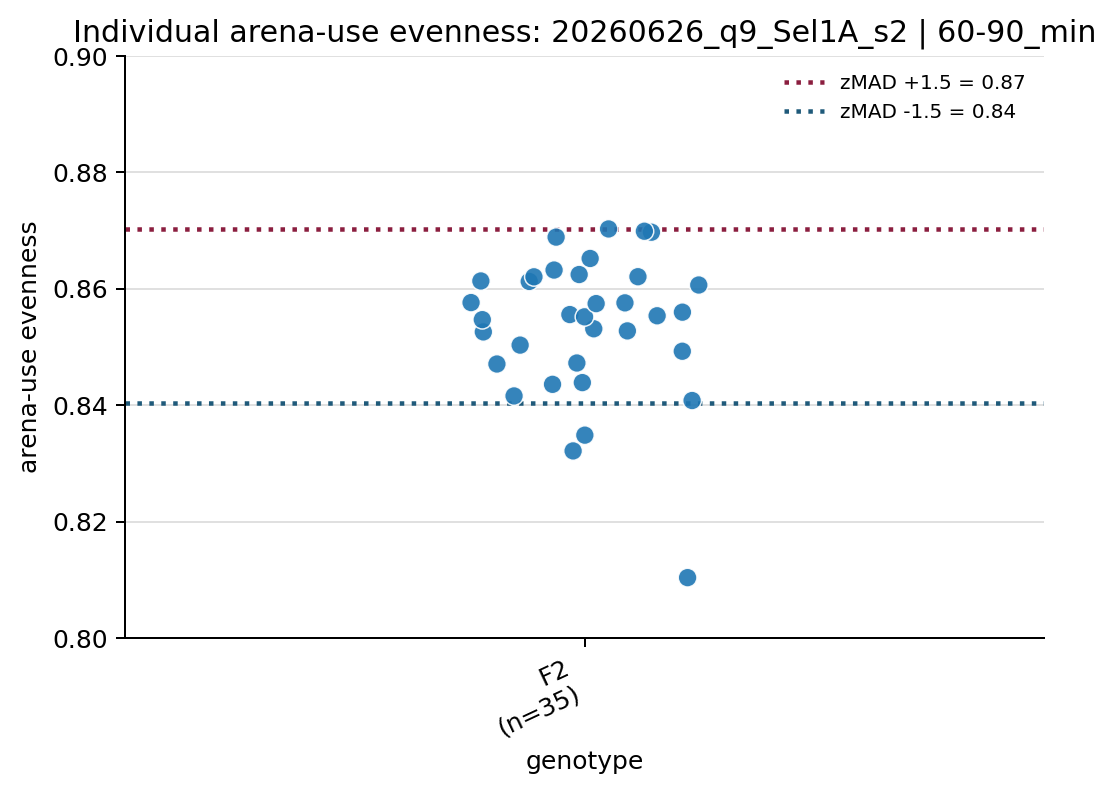

In [13]:
# Plot each fish's arena-use evenness from the movement_metrics table generated above.
required_evenness_plot_columns = {
    'fish_idx',
    'animal_id',
    'genotype',
    'arena_evenness_shannon',
    'arena_evenness_z_mad',
}
missing_evenness_plot_columns = required_evenness_plot_columns - set(movement_metrics.columns)
if missing_evenness_plot_columns:
    raise ValueError('movement_metrics is missing columns: ' + ', '.join(sorted(missing_evenness_plot_columns)))

individual_evenness = movement_metrics.copy()
individual_evenness['genotype'] = individual_evenness['genotype'].astype(str).str.strip().replace('', 'unknown')
individual_evenness = individual_evenness[np.isfinite(individual_evenness['arena_evenness_shannon'])].copy()
genotype_order = sorted(individual_evenness['genotype'].unique())
genotype_counts = individual_evenness.groupby('genotype').size().reindex(genotype_order)
palette_name = 'tab10' if len(genotype_order) <= 10 else 'tab20'
genotype_colors = dict(zip(genotype_order, sns.color_palette(palette_name, n_colors=len(genotype_order))))

np.random.seed(7)
fig_width = max(6, 1.2 * len(genotype_order) + 2)
fig, ax = plt.subplots(figsize=(fig_width, 4.5), dpi=FIGURE_DPI)

sns.stripplot(
    data=individual_evenness,
    x='genotype',
    y='arena_evenness_shannon',
    hue='genotype',
    order=genotype_order,
    hue_order=genotype_order,
    palette=genotype_colors,
    jitter=0.13,
    size=7.5,
    edgecolor='white',
    linewidth=0.6,
    alpha=0.9,
    legend=False,
    ax=ax,
    zorder=3,
)

evenness_values_for_plot = pd.Series(individual_evenness['arena_evenness_shannon'], dtype='float64')
evenness_median_for_plot = evenness_values_for_plot.median(skipna=True)
evenness_mad_for_plot = (evenness_values_for_plot - evenness_median_for_plot).abs().median(skipna=True)
if not pd.isna(evenness_mad_for_plot) and evenness_mad_for_plot != 0:
    zmad_delta = ARENA_EVENNESS_ZMAD_THRESHOLD * evenness_mad_for_plot / 0.6745
    zmad_evenness_lines = [
        (f'zMAD +{ARENA_EVENNESS_ZMAD_THRESHOLD:g}', evenness_median_for_plot + zmad_delta, '#8B1E3F'),
        (f'zMAD -{ARENA_EVENNESS_ZMAD_THRESHOLD:g}', evenness_median_for_plot - zmad_delta, '#1F5A7A'),
    ]
    for zmad_label, evenness_threshold, line_color in zmad_evenness_lines:
        if np.isfinite(evenness_threshold):
            ax.axhline(
                evenness_threshold,
                color=line_color,
                linestyle=':',
                linewidth=1.8,
                label=f'{zmad_label} = {evenness_threshold:.2f}',
                zorder=2,
            )

ax.set_xticks(range(len(genotype_order)))
ax.set_xticklabels([f'{genotype}\n(n={genotype_counts[genotype]})' for genotype in genotype_order], rotation=25, ha='right')
ax.set_ylabel('arena-use evenness')
ax.set_xlabel('genotype')
ax.set_title(
    f'Individual arena-use evenness: {trajectory_meta.get("folder") or trajectory_meta.get("txt_stem", "")}'
    f' | {trajectory_meta.get("window_label", "window")}'
)
ax.set_ylim(0.8, 0.9)
ax.grid(axis='y', color='0.88', linewidth=0.8)
sns.despine(ax=ax)
ax.legend(frameon=False, loc='best', fontsize=8)
fig.tight_layout()

if SAVE_FIGURES:
    folder = trajectory_meta.get('folder') or trajectory_meta.get('txt_stem', '')
    output_base = os.path.join(
        OUTPUT_DIR,
        safe_filename(f'individual_arena_evenness_distribution_{folder}_{trajectory_meta.get("window_label", "window")}')
    )
    fig.savefig(output_base + '.png', dpi=FIGURE_DPI, bbox_inches='tight')
    fig.savefig(output_base + '.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
    individual_evenness.to_csv(output_base + '_arena_evenness_distribution.csv', index=False)
    print('Wrote:', output_base + '.png')
    print('Wrote:', output_base + '.pdf')
    print('Wrote:', output_base + '_arena_evenness_distribution.csv')

display(individual_evenness.sort_values('arena_evenness_shannon', ascending=True).reset_index(drop=True))
plt.show()


Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/individual_occupancy_radius_distribution_20260626_q9_Sel1A_s2_60-90_min.png
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/individual_occupancy_radius_distribution_20260626_q9_Sel1A_s2_60-90_min.pdf
Wrote: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalQTL_temp_output/trajectory_grids/individual_occupancy_radius_distribution_20260626_q9_Sel1A_s2_60-90_min_occupancy_radius_distribution.csv


,fish_idx,animal_id,genotype,valid_samples,valid_intervals,valid_duration_min,total_distance_mm,distance_per_min,mean_speed_mm_s,arena_coverage_fraction,...,arena_evenness_shannon,arena_bias_index,reachable_coverage_fraction,arena_evenness_z_mad,low_arena_evenness_flag,occupancy_radius_z_mad,occupancy_radius_z_mad_abs,occupancy_radius_outlier_flag,low_occupancy_radius_flag,high_occupancy_radius_flag
0,16,297,F2,1800,659,10.983333,341.775221,31.117623,0.518627,0.031168,...,0.514343,0.485657,0.074310,-34.294600,True,-4.349687,4.349687,True,True,False
1,31,312,F2,1800,1788,29.800000,6404.678748,214.922106,3.582035,0.226295,...,0.843919,0.156081,0.343000,-1.153953,False,-1.375098,1.375098,False,False,False
2,27,308,F2,1800,1796,29.933333,6489.999751,216.815136,3.613586,0.269974,...,0.869910,0.130090,0.397345,1.459595,False,-1.143803,1.143803,False,False,False
3,25,306,F2,1800,1775,29.583333,7793.087517,263.428310,4.390472,0.241220,...,0.847111,0.152889,0.348852,-0.832920,False,-1.054238,1.054238,False,False,False
4,8,289,F2,1800,1797,29.950000,7582.571837,253.174352,4.219573,0.256804,...,0.861289,0.138711,0.370547,0.592770,False,-1.023600,1.023600,False,False,False
5,12,293,F2,1800,1799,29.983333,10185.749171,339.713702,5.661895,0.271510,...,0.868900,0.131100,0.390190,1.358118,False,-1.014046,1.014046,False,False,False
6,1,282,F2,1800,1794,29.900000,6871.475183,229.815223,3.830254,0.276119,...,0.869742,0.130258,0.388786,1.442723,False,-0.846833,0.846833,False,False,False
7,11,292,F2,1800,1757,29.283333,6171.812967,210.761968,3.512699,0.253731,...,0.855394,0.144606,0.353121,0.000000,False,-0.711187,0.711187,False,False,False
8,26,307,F2,1800,1799,29.983333,9122.420666,304.249717,5.070829,0.271730,...,0.865232,0.134768,0.376066,0.989189,False,-0.679555,0.679555,False,False,False
9,0,281,F2,1800,1783,29.716667,7484.495732,251.861887,4.197698,0.252195,...,0.852620,0.147380,0.349574,-0.279012,False,-0.674500,0.674500,False,False,False


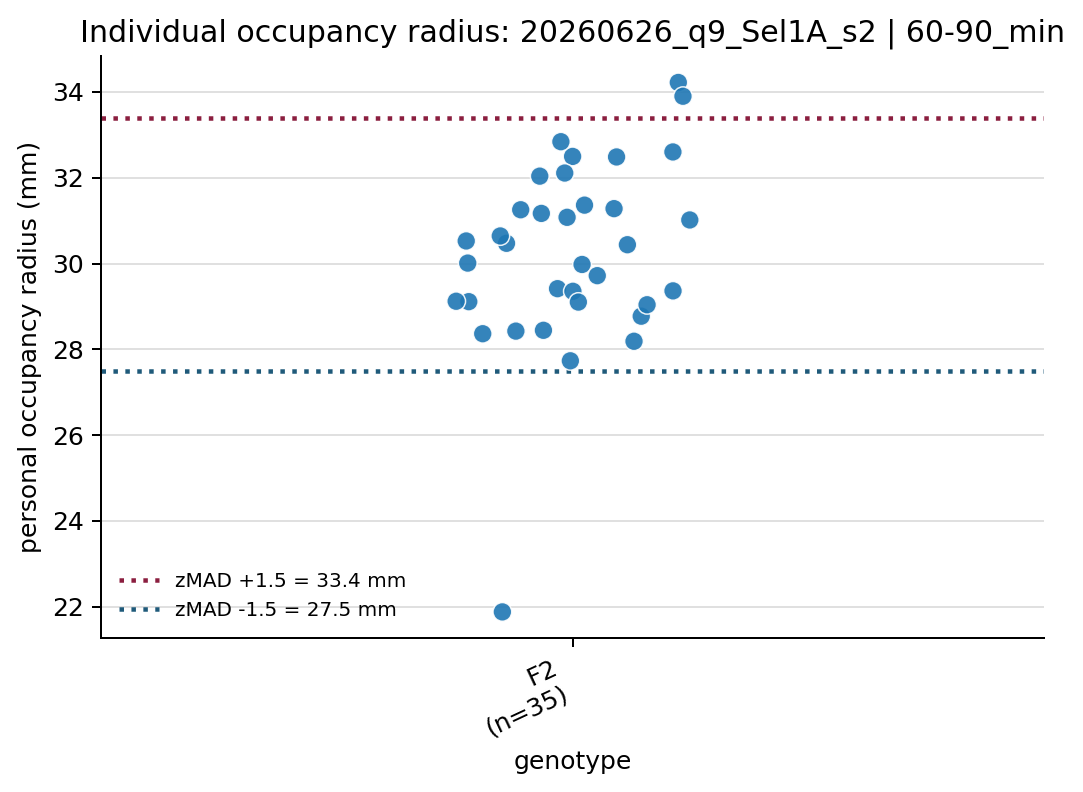

In [11]:
# Plot each fish's personal occupancy radius from the movement_metrics table generated above.
required_radius_plot_columns = {
    'fish_idx',
    'animal_id',
    'genotype',
    'personal_occupancy_radius_mm',
    'occupancy_radius_z_mad',
}
missing_radius_plot_columns = required_radius_plot_columns - set(movement_metrics.columns)
if missing_radius_plot_columns:
    raise ValueError('movement_metrics is missing columns: ' + ', '.join(sorted(missing_radius_plot_columns)))

individual_radius = movement_metrics.copy()
individual_radius['genotype'] = individual_radius['genotype'].astype(str).str.strip().replace('', 'unknown')
individual_radius = individual_radius[np.isfinite(individual_radius['personal_occupancy_radius_mm'])].copy()
genotype_order = sorted(individual_radius['genotype'].unique())
genotype_counts = individual_radius.groupby('genotype').size().reindex(genotype_order)
palette_name = 'tab10' if len(genotype_order) <= 10 else 'tab20'
genotype_colors = dict(zip(genotype_order, sns.color_palette(palette_name, n_colors=len(genotype_order))))

np.random.seed(7)
fig_width = max(6, 1.2 * len(genotype_order) + 2)
fig, ax = plt.subplots(figsize=(fig_width, 4.5), dpi=FIGURE_DPI)

sns.stripplot(
    data=individual_radius,
    x='genotype',
    y='personal_occupancy_radius_mm',
    hue='genotype',
    order=genotype_order,
    hue_order=genotype_order,
    palette=genotype_colors,
    jitter=0.13,
    size=7.5,
    edgecolor='white',
    linewidth=0.6,
    alpha=0.9,
    legend=False,
    ax=ax,
    zorder=3,
)

radius_values_for_plot = pd.Series(individual_radius['personal_occupancy_radius_mm'], dtype='float64')
radius_median_for_plot = radius_values_for_plot.median(skipna=True)
radius_mad_for_plot = (radius_values_for_plot - radius_median_for_plot).abs().median(skipna=True)
if not pd.isna(radius_mad_for_plot) and radius_mad_for_plot != 0:
    zmad_delta = ARENA_RADIUS_ZMAD_THRESHOLD * radius_mad_for_plot / 0.6745
    zmad_radius_lines = [
        (f'zMAD +{ARENA_RADIUS_ZMAD_THRESHOLD:g}', radius_median_for_plot + zmad_delta, '#8B1E3F'),
        (f'zMAD -{ARENA_RADIUS_ZMAD_THRESHOLD:g}', radius_median_for_plot - zmad_delta, '#1F5A7A'),
    ]
    for zmad_label, radius_threshold, line_color in zmad_radius_lines:
        if np.isfinite(radius_threshold):
            ax.axhline(
                radius_threshold,
                color=line_color,
                linestyle=':',
                linewidth=1.8,
                label=f'{zmad_label} = {radius_threshold:.1f} mm',
                zorder=2,
            )

ax.set_xticks(range(len(genotype_order)))
ax.set_xticklabels([f'{genotype}\n(n={genotype_counts[genotype]})' for genotype in genotype_order], rotation=25, ha='right')
ax.set_ylabel('personal occupancy radius (mm)')
ax.set_xlabel('genotype')
ax.set_title(
    f'Individual occupancy radius: {trajectory_meta.get("folder") or trajectory_meta.get("txt_stem", "")}'
    f' | {trajectory_meta.get("window_label", "window")}'
)
ax.grid(axis='y', color='0.88', linewidth=0.8)
sns.despine(ax=ax)
ax.legend(frameon=False, loc='best', fontsize=8)
fig.tight_layout()

if SAVE_FIGURES:
    folder = trajectory_meta.get('folder') or trajectory_meta.get('txt_stem', '')
    output_base = os.path.join(
        OUTPUT_DIR,
        safe_filename(f'individual_occupancy_radius_distribution_{folder}_{trajectory_meta.get("window_label", "window")}')
    )
    fig.savefig(output_base + '.png', dpi=FIGURE_DPI, bbox_inches='tight')
    fig.savefig(output_base + '.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
    individual_radius.to_csv(output_base + '_occupancy_radius_distribution.csv', index=False)
    print('Wrote:', output_base + '.png')
    print('Wrote:', output_base + '.pdf')
    print('Wrote:', output_base + '_occupancy_radius_distribution.csv')

display(individual_radius.sort_values('occupancy_radius_z_mad', ascending=True).reset_index(drop=True))
plt.show()
